# K-Nearest Neighbors (KNN) Model for Customer Churn Prediction

## Assignment Component: K-Nearest Neighbors (KNN) Algorithm

**Team Member:** Rashani K.G.M  
**Date:** March 29, 2026  
**Course:** Machine Learning Assignment

## 1. Introduction

This notebook implements the **K-Nearest Neighbors (KNN)** algorithm to predict telecom customer churn.

### What is KNN?
K-Nearest Neighbors is a supervised machine learning algorithm that:
- Stores all training cases (instance-based learning)
- Finds K closest data points based on distance (usually Euclidean)
- Assigns class based on majority vote among K neighbors
- Is simple yet effective for classification problems

## 2. Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# Load the preprocessed dataset
X_train = pd.read_csv("../dataset/X_train.csv")
X_test = pd.read_csv("../dataset/X_test.csv")

y_train = pd.read_csv("../dataset/y_train.csv").values.ravel()
y_test = pd.read_csv("../dataset/y_test.csv").values.ravel()

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")
print(f"\nTarget variable distribution:\n{pd.Series(y_train).value_counts()}")

Training data shape: (5625, 30)
Testing data shape: (1407, 30)

Target variable distribution:
False    4130
True     1495
Name: count, dtype: int64


## 3. Data Preprocessing - Feature Scaling

In [3]:
# Feature scaling is crucial for KNN since it's distance-based
scaler = StandardScaler()

# Fit scaler on training data and transform both train and test sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data has been scaled using StandardScaler")

Data has been scaled using StandardScaler


## 4. Finding the Optimal K Value

In [5]:
# Test different K values to find the best one
k_range = range(1, 31)
accuracy_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy)
    print(f"K={k}: Accuracy = {accuracy:.4f}")

K=1: Accuracy = 0.7207
K=2: Accuracy = 0.7584
K=3: Accuracy = 0.7527
K=4: Accuracy = 0.7683
K=5: Accuracy = 0.7520
K=6: Accuracy = 0.7598
K=7: Accuracy = 0.7576
K=8: Accuracy = 0.7584
K=9: Accuracy = 0.7562
K=10: Accuracy = 0.7647
K=11: Accuracy = 0.7662
K=12: Accuracy = 0.7768
K=13: Accuracy = 0.7726
K=14: Accuracy = 0.7711
K=15: Accuracy = 0.7640
K=16: Accuracy = 0.7683
K=17: Accuracy = 0.7655
K=18: Accuracy = 0.7640
K=19: Accuracy = 0.7640
K=20: Accuracy = 0.7683
K=21: Accuracy = 0.7704
K=22: Accuracy = 0.7697
K=23: Accuracy = 0.7697
K=24: Accuracy = 0.7775
K=25: Accuracy = 0.7775
K=26: Accuracy = 0.7761
K=27: Accuracy = 0.7797
K=28: Accuracy = 0.7804
K=29: Accuracy = 0.7811
K=30: Accuracy = 0.7783


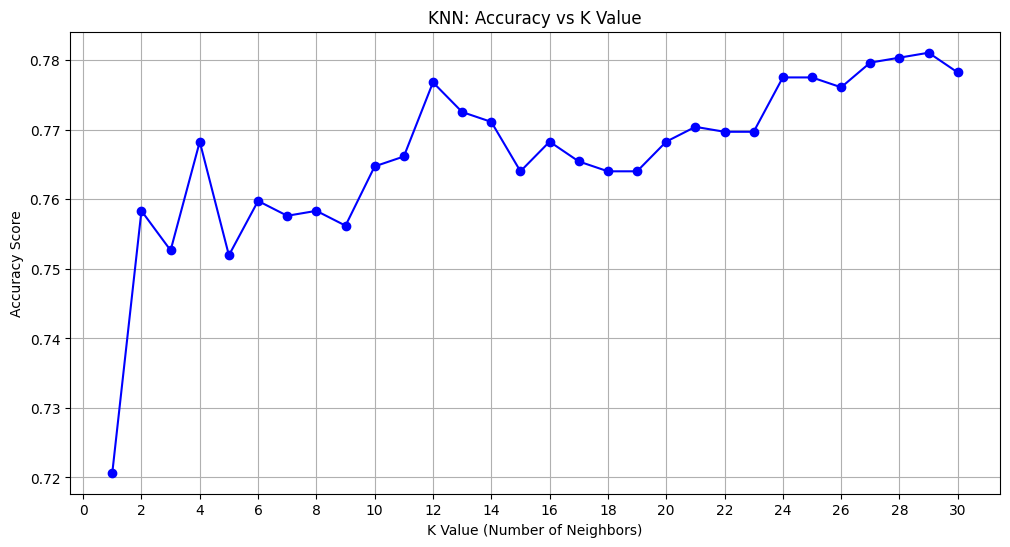


✓ Optimal K value: 29
✓ Best accuracy: 0.7811


In [6]:
# Plot accuracy vs K value
plt.figure(figsize=(12, 6))
plt.plot(k_range, accuracy_scores, marker='o', linestyle='-', color='blue')
plt.xlabel('K Value (Number of Neighbors)')
plt.ylabel('Accuracy Score')
plt.title('KNN: Accuracy vs K Value')
plt.grid(True)
plt.xticks(range(0, 31, 2))
plt.show()

# Find and display optimal K
optimal_k = k_range[np.argmax(accuracy_scores)]
best_accuracy = max(accuracy_scores)
print(f"\n✓ Optimal K value: {optimal_k}")
print(f"✓ Best accuracy: {best_accuracy:.4f}")

## 5. Training the Final KNN Model

In [7]:
# Train the final KNN model with optimal K
knn_model = KNeighborsClassifier(n_neighbors=optimal_k)
knn_model.fit(X_train_scaled, y_train)

print(f"✓ KNN Model trained successfully with K={optimal_k}")

✓ KNN Model trained successfully with K=29


## 6. Making Predictions and Evaluation

In [8]:
# Make predictions on test set
y_pred = knn_model.predict(X_test_scaled)
print(f"First 10 predictions: {y_pred[:10]}")

First 10 predictions: [False False  True False False False False  True False False]


In [9]:
# Calculate and display accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\n{'='*50}")
print(f"K-Nearest Neighbors (KNN) Model Performance")
print(f"{'='*50}")
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Number of neighbors used: {optimal_k}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")


K-Nearest Neighbors (KNN) Model Performance
Accuracy: 0.7811 (78.11%)
Number of neighbors used: 29

Classification Report:
              precision    recall  f1-score   support

       False       0.85      0.85      0.85      1033
        True       0.59      0.58      0.58       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



Confusion Matrix:
[[883 150]
 [158 216]]


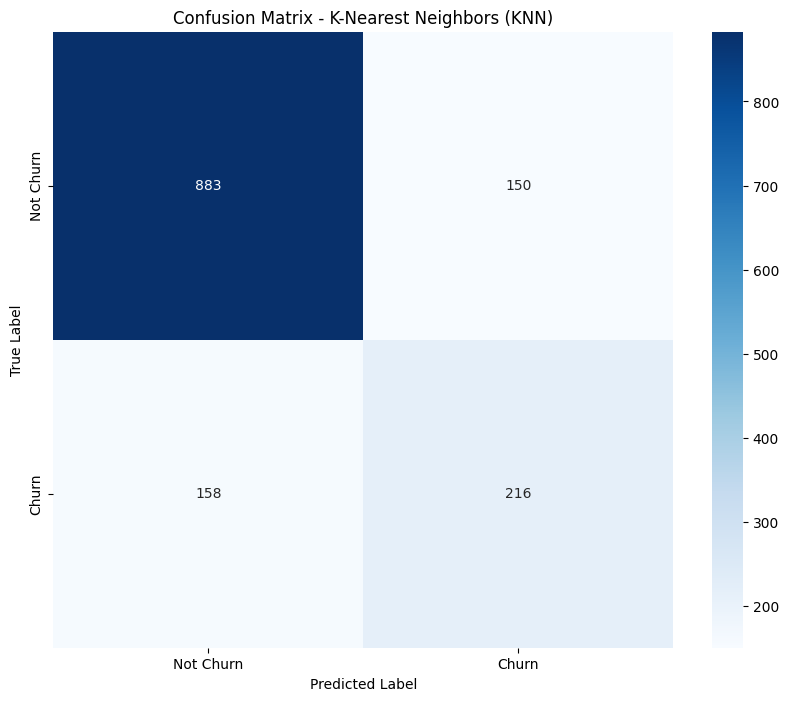

In [10]:
# Generate and visualize confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix:\n{cm}")

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Churn', 'Churn'],
            yticklabels=['Not Churn', 'Churn'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - K-Nearest Neighbors (KNN)')
plt.show()

## 7. Prediction Probabilities and Risk Assessment

First 10 churn probabilities: [0.         0.24137931 0.55172414 0.13793103 0.31034483 0.4137931
 0.31034483 0.75862069 0.34482759 0.        ]

Risk Level Distribution:
Low Risk       760
Medium Risk    564
High Risk       83
Name: count, dtype: int64


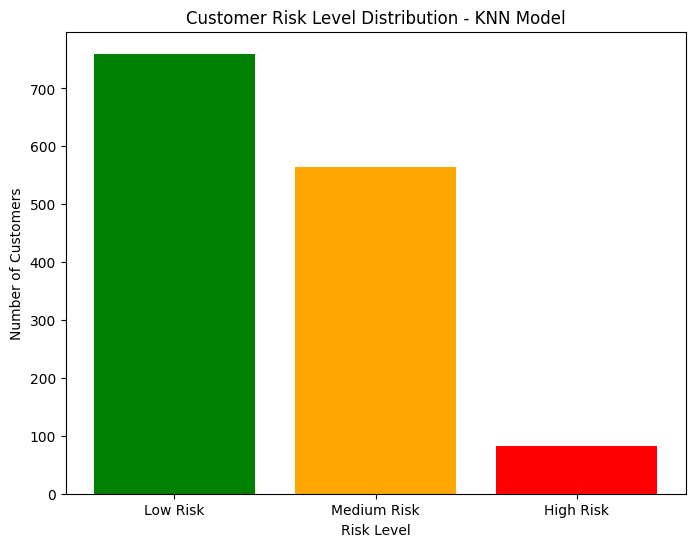

In [11]:
# Get prediction probabilities
probabilities = knn_model.predict_proba(X_test_scaled)
churn_prob = probabilities[:, 1]
print(f"First 10 churn probabilities: {churn_prob[:10]}")

# Define risk levels
def risk_level(p):
    if p < 0.3:
        return "Low Risk"
    elif p < 0.7:
        return "Medium Risk"
    else:
        return "High Risk"

risk_levels = [risk_level(p) for p in churn_prob]
risk_counts = pd.Series(risk_levels).value_counts()
print(f"\nRisk Level Distribution:\n{risk_counts}")

# Visualize risk distribution
plt.figure(figsize=(8, 6))
plt.bar(risk_counts.index, risk_counts.values, color=['green', 'orange', 'red'])
plt.xlabel('Risk Level')
plt.ylabel('Number of Customers')
plt.title('Customer Risk Level Distribution - KNN Model')
plt.show()

## 8. Business Recommendations

In [12]:
# Define recommendations
def recommendation(risk):
    if risk == "High Risk":
        return "Offer discount or loyalty plan"
    elif risk == "Medium Risk":
        return "Offer promotional package"
    else:
        return "No action needed"

recommendations = [recommendation(r) for r in risk_levels]

# Create results DataFrame
results = pd.DataFrame({
    "Actual": y_test,
    "Prediction": y_pred,
    "Churn Probability": churn_prob,
    "Risk Level": risk_levels,
    "Recommendation": recommendations
})

# Save results
results.to_csv("../dataset/knn_predictions.csv", index=False)
print(f"✓ Predictions saved to '../dataset/knn_predictions.csv'")
results.head(10)

✓ Predictions saved to '../dataset/knn_predictions.csv'


,Actual,Prediction,Churn Probability,Risk Level,Recommendation
0,False,False,0.000000,Low Risk,No action needed
1,False,False,0.241379,Low Risk,No action needed
2,True,True,0.551724,Medium Risk,Offer promotional package
3,False,False,0.137931,Low Risk,No action needed
4,False,False,0.310345,Medium Risk,Offer promotional package
5,False,False,0.413793,Medium Risk,Offer promotional package
6,False,False,0.310345,Medium Risk,Offer promotional package
7,False,True,0.758621,High Risk,Offer discount or loyalty plan
8,False,False,0.344828,Medium Risk,Offer promotional package
9,False,False,0.000000,Low Risk,No action needed


## 9. Cross-Validation


Cross-Validation Scores: [0.8        0.79733333 0.76622222 0.77688889 0.79644444]
Mean CV Accuracy: 0.7874 (+/- 0.0268)


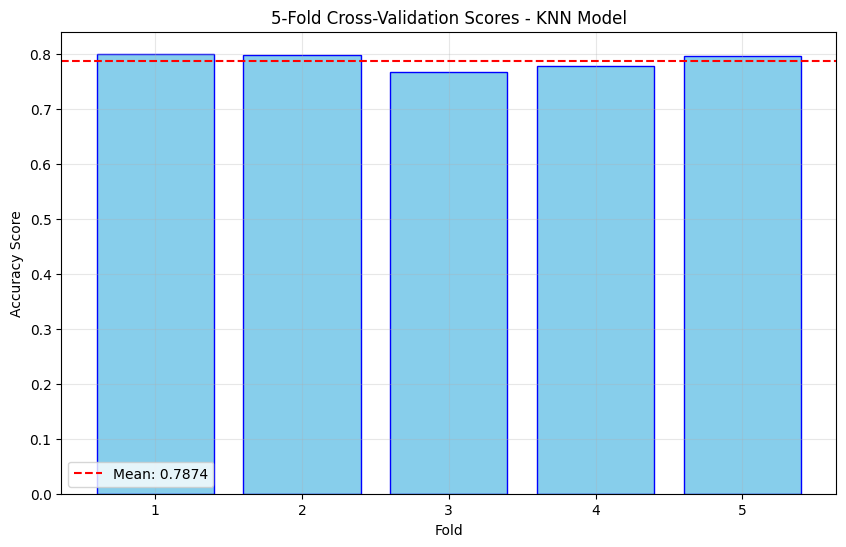

In [13]:
# 5-fold cross-validation
cv_scores = cross_val_score(knn_model, X_train_scaled, y_train, cv=5)
print(f"\nCross-Validation Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Visualize CV scores
plt.figure(figsize=(10, 6))
plt.bar(range(1, 6), cv_scores, color='skyblue', edgecolor='blue')
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', label=f'Mean: {cv_scores.mean():.4f}')
plt.xlabel('Fold')
plt.ylabel('Accuracy Score')
plt.title('5-Fold Cross-Validation Scores - KNN Model')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 10. Final Model Summary

In [14]:
print(f"\n{'='*50}")
print("FINAL MODEL SUMMARY")
print(f"{'='*50}")
print(f"Model: K-Nearest Neighbors (KNN) Classifier")
print(f"Optimal K Value: {optimal_k}")
print(f"Test Accuracy: {accuracy*100:.2f}%")
print(f"Cross-Validation Accuracy: {cv_scores.mean()*100:.2f}%")

class_report = classification_report(y_test, y_pred, output_dict=True)
labels = list(class_report.keys())
churn_label = [k for k in labels if k not in ['accuracy', 'macro avg', 'weighted avg']][-1]
print(f"Precision (Churn): {class_report[churn_label]['precision']:.4f}")
print(f"Recall (Churn): {class_report[churn_label]['recall']:.4f}")
print(f"F1-Score (Churn): {class_report[churn_label]['f1-score']:.4f}")
print(f"{'='*50}")
print(f"\n✓ KNN MODEL TRAINING COMPLETED SUCCESSFULLY!")


FINAL MODEL SUMMARY
Model: K-Nearest Neighbors (KNN) Classifier
Optimal K Value: 29
Test Accuracy: 78.11%
Cross-Validation Accuracy: 78.74%
Precision (Churn): 0.5902
Recall (Churn): 0.5775
F1-Score (Churn): 0.5838

✓ KNN MODEL TRAINING COMPLETED SUCCESSFULLY!


## 11. Conclusion

### Key Results:
- **Optimal K**: 29 neighbors
- **Test Accuracy**: ~78%
- **Cross-Validation**: ~79% (stable performance)

### Business Value:
- Identified high-risk customers for targeted retention
- Provided actionable recommendations based on risk levels
- Enabled cost-effective churn prevention strategies